# Per-channel (A, E, T) SNR vs dt

Interactive version of `snr_channels_dt.py` (the same functions are imported, so the notebook and the batch job cannot drift apart).

A signal with power above Nyquist (0.5/dt) aliases, and the tell is spurious power in the near-null **T** channel. If the A/E/T split is stable across dt the signal is resolved; if T grows as dt coarsens, it is aliasing.

Needs a GPU for speed (it falls back to NumPy on CPU, but a 0.5 yr waveform at dt = 2.5 s is slow there). Kernel: `/home/svu/e1583490/bias_inference_emri/.venv`.

In [4]:
import os, sys
HERE = "/home/svu/e1583490/EMRI_CV_bias/environemen_2_eccen/summary"
sys.path[:0] = [HERE, os.path.dirname(HERE)]

import numpy as np
import matplotlib.pyplot as plt
from snr_channels_dt import measure, write_md, OUT
from fisher_bestfit import CONFIGS
print("sets available:", list(CONFIGS))

sets available: ['set 1', 'set 2', 'set 3', 'set 4', 'set 5']


## Choose what to run
`CASES` are `(dt [s], fmax [Hz])`; `fmax = None` means up to Nyquist. The pipeline band is `[1e-5, 0.1]` Hz.

In [5]:
SETS = ["set 4", "set 5"]
CASES = [(2.5, 0.1), (2.5, None), (5.0, 0.1), (10.0, 0.05)]

## Run

In [6]:
rows = []
for tag in SETS:
    for dt, fmax in CASES:
        rows.append(measure(tag, dt, fmax))

[CONF] T = 0.495521 yr (0.99 x plunge), dt = 2.5 s, 3 channels, band [1.0e-05, 1.0e-01] Hz
[SNR ] set 4 dt = 2.5 s, band [1e-05, 0.1] Hz: SNR = 316.337231
[CHAN] A: SNR 126.4908 (15.9889% of SNR^2)  E: SNR 289.9290 (84.0006% of SNR^2)  T: SNR 3.2419 (0.0105% of SNR^2)
[CONF] T = 0.495521 yr (0.99 x plunge), dt = 2.5 s, 3 channels, band [1.0e-05, 2.0e-01] Hz
[SNR ] set 4 dt = 2.5 s, band [1e-05, 0.2] Hz: SNR = 1133358.146666
[CHAN] A: SNR 126.9146 (0.0000% of SNR^2)  E: SNR 291.2046 (0.0000% of SNR^2)  T: SNR 1133358.1021 (100.0000% of SNR^2)
[CONF] T = 0.495521 yr (0.99 x plunge), dt = 5.0 s, 3 channels, band [1.0e-05, 1.0e-01] Hz
[SNR ] set 4 dt = 5 s, band [1e-05, 0.1] Hz: SNR = 351.347395
[CHAN] A: SNR 120.7085 (11.8033% of SNR^2)  E: SNR 329.9613 (88.1967% of SNR^2)  T: SNR 0.0811 (0.0000% of SNR^2)
[CONF] T = 0.495521 yr (0.99 x plunge), dt = 10.0 s, 3 channels, band [1.0e-05, 5.0e-02] Hz
[SNR ] set 4 dt = 10 s, band [1e-05, 0.05] Hz: SNR = 81.718737
[CHAN] A: SNR 60.4644 (54.7464

## Table

In [7]:
print(f"{'set':6}{'dt':>5}{'fmax':>7}{'SNR':>11}{'A SNR':>10}{'E SNR':>10}{'T SNR':>10}{'A %':>9}{'E %':>9}{'T %':>9}")
for r in rows:
    c, s = r["channel_snr"], r["channel_share"]
    print(f"{r['set']:6}{r['dt']:5g}{r['fmax']:7g}{r['snr']:11.4f}{c['A']:10.4f}{c['E']:10.4f}{c['T']:10.4f}"
          f"{100*s['A']:9.4f}{100*s['E']:9.4f}{100*s['T']:9.4f}")

set      dt   fmax        SNR     A SNR     E SNR     T SNR      A %      E %      T %
set 4   2.5    0.1   316.3372  126.4908  289.9290    3.2419  15.9889  84.0006   0.0105
set 4   2.5    0.21133358.1467  126.9146  291.20461133358.1021   0.0000   0.0000 100.0000
set 4     5    0.1   351.3474  120.7085  329.9613    0.0811  11.8033  88.1967   0.0000
set 4    10   0.05    81.7187   60.4644   54.9728    0.0817  54.7464  45.2535   0.0001
set 5   2.5    0.1    85.7025   63.0473   57.9511    3.4118  54.1185  45.7230   0.1585
set 5   2.5    0.2   183.1565   63.0634   57.9535  161.8972  11.8552  10.0119  78.1329
set 5     5    0.1    85.7017   63.0300   57.6652    6.8361  54.0897  45.2740   0.6363
set 5    10   0.05    85.6327   62.9729   58.0289    0.0847  54.0790  45.9209   0.0001


## Channel share of SNR² vs dt

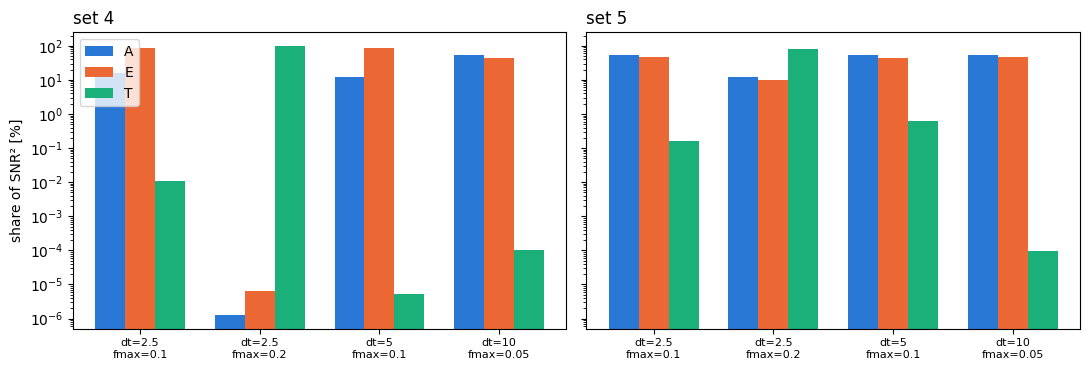

In [8]:
COLOR = {"A": "#2a78d6", "E": "#eb6834", "T": "#1baf7a"}
fig, axes = plt.subplots(1, len(SETS), figsize=(5.5 * len(SETS), 3.8), sharey=True, squeeze=False)
for ax, tag in zip(axes[0], SETS):
    rs = [r for r in rows if r["set"] == tag]
    labels = [f"dt={r['dt']:g}\nfmax={r['fmax']:g}" for r in rs]
    x = np.arange(len(rs))
    for k, ch in enumerate("AET"):
        ax.bar(x + (k - 1) * 0.25, [100 * r["channel_share"][ch] for r in rs], 0.25,
               color=COLOR[ch], label=ch)
    ax.set_xticks(x, labels, fontsize=8)
    ax.set_title(tag, loc="left")
    ax.set_yscale("log")
axes[0][0].set_ylabel("share of SNR² [%]")
axes[0][0].legend(loc="upper left")
fig.tight_layout()

## Save (same files as the batch job)

In [9]:
import json
json.dump(rows, open(OUT + ".json", "w"), indent=1)
write_md(rows)
print("wrote", OUT + ".json", OUT + ".md")

wrote /home/svu/e1583490/EMRI_CV_bias/environemen_2_eccen/summary/snr_channels_dt.json /home/svu/e1583490/EMRI_CV_bias/environemen_2_eccen/summary/snr_channels_dt.md


---
# Diagnostics: is set 4's signal clean?

Set 4's SNR *in the same band* changes with dt (351 at dt = 5, 316 at dt = 2.5), and at dt = 10 it is 82 with the same A/E split as every other set. A resolved physical signal cannot do that; set 5 does not. The cells below find **where in frequency and time** set 4's extra SNR lives, and whether the disk or the waveform itself is responsible.

Functions live in `waveform_diagnostics.py` and use the pipeline's own signal, PSD and inner-product conventions.

In [10]:
import importlib, waveform_diagnostics as wd
importlib.reload(wd)
from scipy.signal import spectrogram

D = {
    "set 4, dt=5":   wd.load_signal("set 4", dt=5.0),
    "set 4, dt=2.5": wd.load_signal("set 4", dt=2.5),
    "set 5, dt=5":   wd.load_signal("set 5", dt=5.0),
}
S = {k: wd.snr_density(d) for k, d in D.items()}
for k in D:
    print(f"{k:14}  pipeline SNR {D[k]['snr']:9.4f}   density SNR {S[k]['snr']:9.4f}   "
          + "  ".join(f"{c} {v:8.3f}" for c, v in S[k]['channel_snr'].items()))

[CONF] T = 0.495521 yr (0.99 x plunge), dt = 5.0 s, 3 channels, band [1.0e-05, 1.0e-01] Hz
[CONF] T = 0.495521 yr (0.99 x plunge), dt = 2.5 s, 3 channels, band [1.0e-05, 1.0e-01] Hz
[CONF] T = 0.501229 yr (0.99 x plunge), dt = 5.0 s, 3 channels, band [1.0e-05, 1.0e-01] Hz
set 4, dt=5     pipeline SNR  351.3474   density SNR  351.3474   A  120.708  E  329.961  T    0.081
set 4, dt=2.5   pipeline SNR  316.3372   density SNR  316.3372   A  126.491  E  289.929  T    3.242
set 5, dt=5     pipeline SNR   85.7017   density SNR   85.7017   A   63.030  E   57.665  T    6.836


## 1. Where in frequency does the SNR accumulate?
Cumulative SNR² vs frequency, per channel. A smooth inspiral climbs over the band its orbital harmonics sweep; an artifact shows as a step or a climb at frequencies the orbit never reaches.

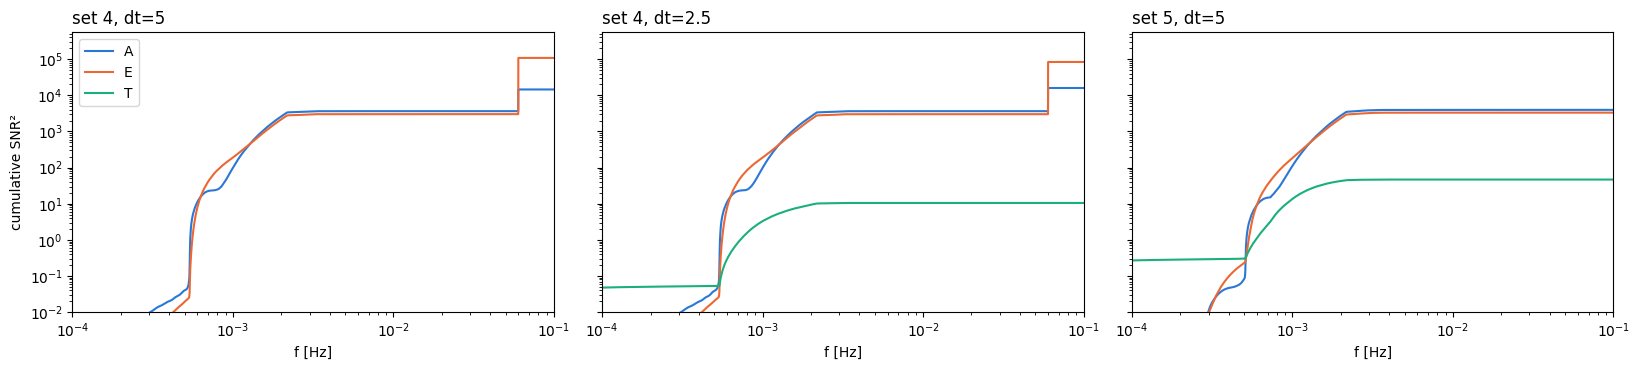

In [11]:
COLOR = {"A": "#2a78d6", "E": "#eb6834", "T": "#1baf7a"}
fig, axes = plt.subplots(1, len(D), figsize=(5.5 * len(D), 3.8), sharey=True)
for ax, (k, s) in zip(axes, S.items()):
    for i, c in enumerate("AET"):
        ax.plot(s["f"], s["cumulative"][i], color=COLOR[c], lw=1.5, label=c)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_ylim(1e-2, None)
    ax.set_xlim(1e-4, D[k]["fmax"]); ax.set_title(k, loc="left"); ax.set_xlabel("f [Hz]")
axes[0].set_ylabel("cumulative SNR²"); axes[0].legend(loc="upper left")
fig.tight_layout()

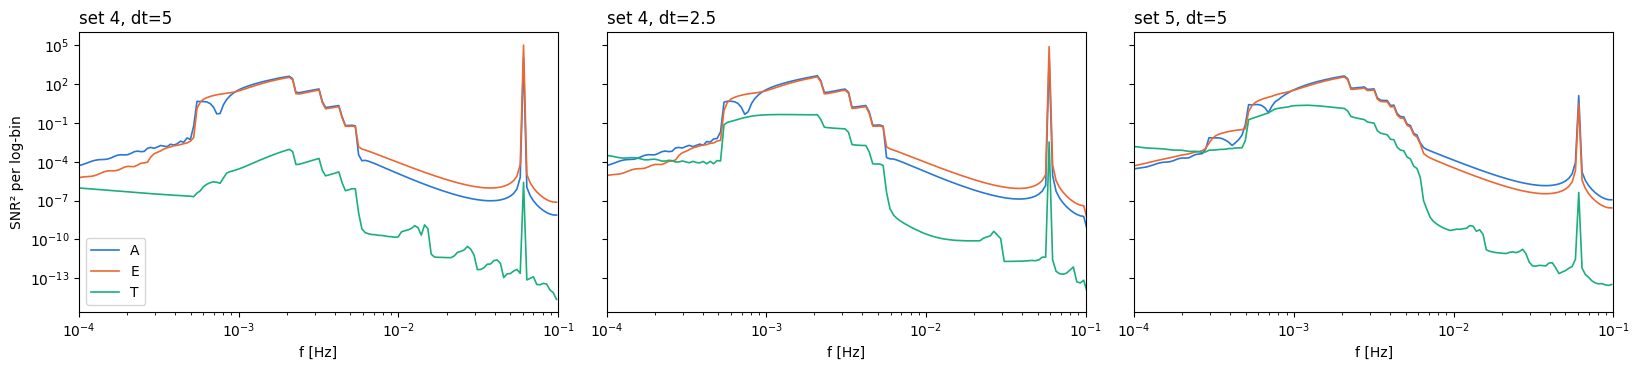

In [12]:
# SNR² per frequency bin, log-binned so the spectrum is readable
def log_binned(f, y, nb=300):
    edges = np.logspace(np.log10(f[f > 0].min()), np.log10(f.max()), nb + 1)
    idx = np.digitize(f, edges)
    tot = np.bincount(idx, weights=y, minlength=nb + 2)[1:nb + 1]
    return np.sqrt(edges[:-1] * edges[1:]), tot

fig, axes = plt.subplots(1, len(D), figsize=(5.5 * len(D), 3.8), sharey=True)
for ax, (k, s) in zip(axes, S.items()):
    for i, c in enumerate("AET"):
        fc, y = log_binned(s["f"], s["density"][i])
        ax.plot(fc, np.where(y > 0, y, np.nan), color=COLOR[c], lw=1.2, label=c)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(1e-4, D[k]["fmax"]); ax.set_title(k, loc="left"); ax.set_xlabel("f [Hz]")
axes[0].set_ylabel("SNR² per log-bin"); axes[0].legend(loc="lower left")
fig.tight_layout()

## 2. Glitch check in the time domain
`jump_ratio` = largest sample-to-sample jump / median jump. A smooth inspiral gives a modest number; a discontinuity or spike stands out by orders of magnitude. `t_*` are in days from the start.

In [13]:
for k, d in D.items():
    print(k)
    for c, r in wd.glitch_report(d).items():
        print(f"   {c}: nonfinite {r['nonfinite']}, max|x| {r['max_abs']:.3e} at {r['t_max_abs_days']:.3f} d, "
              f"largest jump at {r['t_max_jump_days']:.3f} d, jump ratio {r['jump_ratio']:.3g}")

set 4, dt=5
   A: nonfinite 0, max|x| 1.096e-22 at 180.873 d, largest jump at 180.877 d, jump ratio 978
   E: nonfinite 0, max|x| 1.083e-22 at 180.872 d, largest jump at 180.877 d, jump ratio 1.62e+03
   T: nonfinite 0, max|x| 9.656e-27 at 180.841 d, largest jump at 180.861 d, jump ratio 193
set 4, dt=2.5


   A: nonfinite 0, max|x| 1.095e-22 at 180.873 d, largest jump at 180.877 d, jump ratio 2.21e+03
   E: nonfinite 0, max|x| 1.079e-22 at 180.872 d, largest jump at 180.877 d, jump ratio 3.2e+03
   T: nonfinite 0, max|x| 1.335e-25 at 180.872 d, largest jump at 180.877 d, jump ratio 1.03e+03
set 5, dt=5
   A: nonfinite 0, max|x| 1.330e-22 at 182.906 d, largest jump at 182.961 d, jump ratio 3.76e+03
   E: nonfinite 0, max|x| 1.336e-22 at 182.958 d, largest jump at 182.961 d, jump ratio 1.17e+03
   T: nonfinite 0, max|x| 3.136e-25 at 182.959 d, largest jump at 182.958 d, jump ratio 644


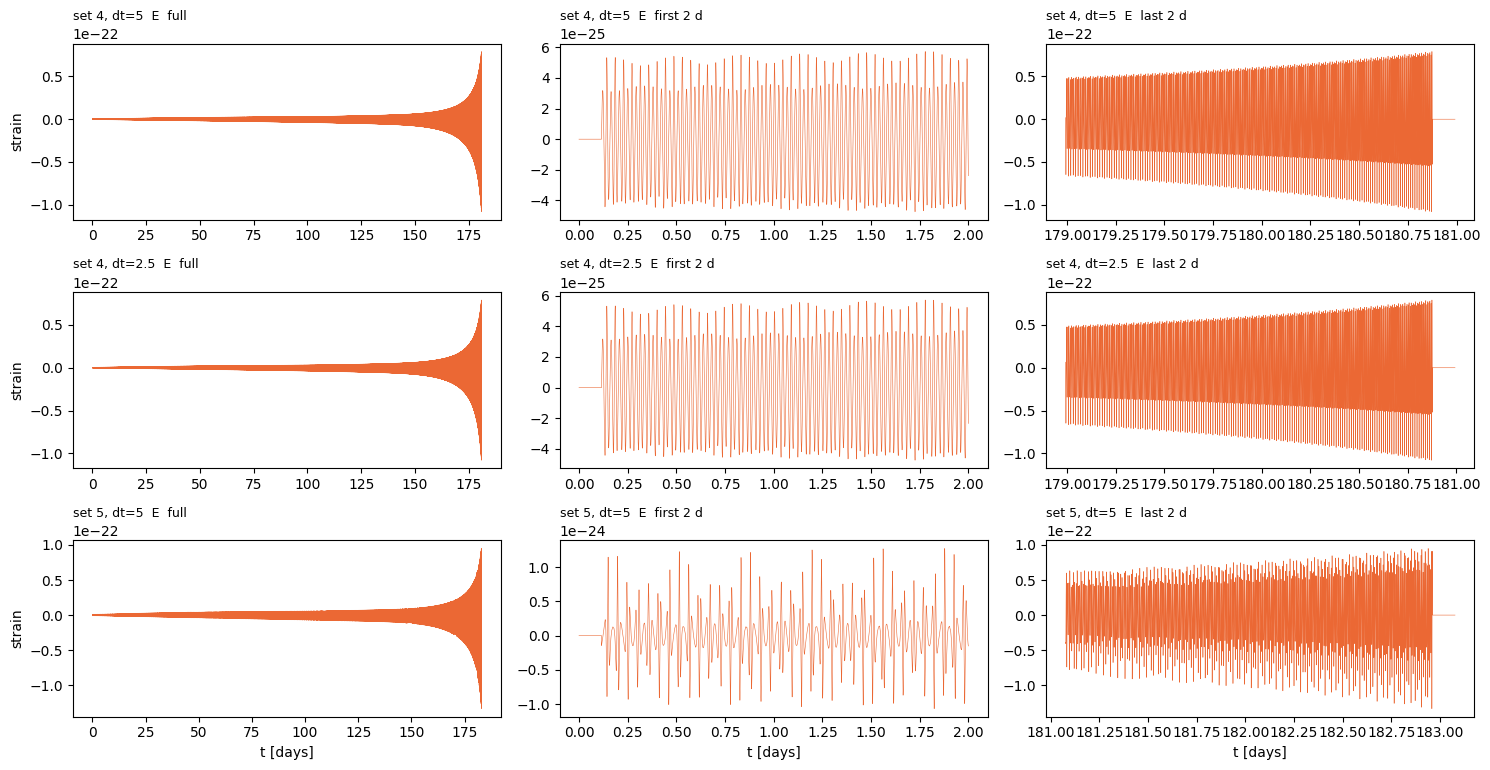

In [14]:
# full span, then the first and last two days, E channel (where set 4's excess sits)
CH = 1   # 0 = A, 1 = E, 2 = T
windows = [("full", None), ("first 2 d", (0, 2)), ("last 2 d", (-2, None))]
fig, axes = plt.subplots(len(D), len(windows), figsize=(15, 2.6 * len(D)), squeeze=False)
for row, (k, d) in zip(axes, D.items()):
    tday = d["t"] / 86400
    for ax, (name, w) in zip(row, windows):
        if w is None:
            sl = slice(None)
        elif w[0] >= 0:
            sl = tday < w[1]
        else:
            sl = tday > tday[-1] + w[0]
        ax.plot(tday[sl], d["signal"][CH][sl], lw=0.4, color=COLOR["AET"[CH]])
        ax.set_title(f"{k}  {'AET'[CH]}  {name}", loc="left", fontsize=9)
    row[0].set_ylabel("strain")
for ax in axes[-1]:
    ax.set_xlabel("t [days]")
fig.tight_layout()

## 3. Spectrogram (E channel)
The orbital harmonics should appear as smooth chirping tracks. Broadband vertical stripes = glitches; horizontal lines at fixed frequency = numerical artefacts.

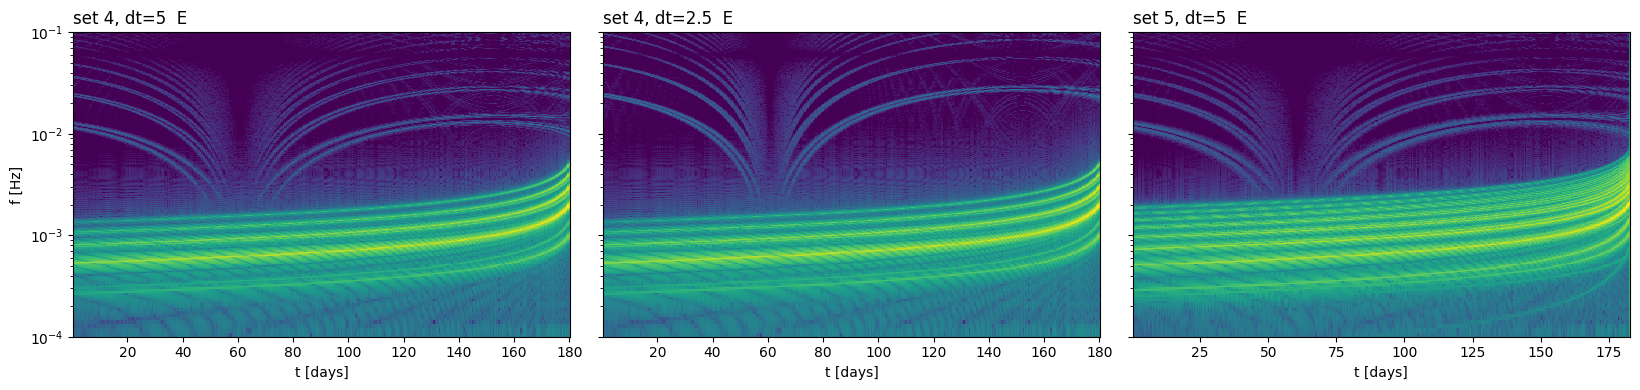

In [15]:
fig, axes = plt.subplots(1, len(D), figsize=(5.5 * len(D), 4), sharey=True)
for ax, (k, d) in zip(axes, D.items()):
    nper = int(86400 / d["dt"])                       # one-day segments
    f, t, Sxx = spectrogram(d["signal"][CH], fs=1 / d["dt"], nperseg=nper, noverlap=nper // 2)
    ax.pcolormesh(t / 86400, f, 10 * np.log10(Sxx + 1e-300), shading="auto",
                  vmin=np.percentile(10 * np.log10(Sxx + 1e-300), 50))
    ax.set_yscale("log"); ax.set_ylim(1e-4, 0.5 / d["dt"])
    ax.set_title(f"{k}  {'AET'[CH]}", loc="left"); ax.set_xlabel("t [days]")
axes[0].set_ylabel("f [Hz]")
fig.tight_layout()

## 4. Disk or waveform? Vacuum at the same parameters
The same waveform class, response and T, with the disk switched off. If the vacuum waveform shows the same excess, the problem is the waveform at e0 = 0.0125, not the disk.

In [16]:
for k in ("set 4, dt=5", "set 5, dt=5"):
    vac = wd.load_vacuum(D[k])
    sv = wd.snr_density(D[k], signal=vac)
    print(f"{k:12}  disk SNR {S[k]['snr']:9.4f}   vacuum SNR {sv['snr']:9.4f}   vacuum "
          + "  ".join(f"{c} {v:8.3f}" for c, v in sv['channel_snr'].items()))
    for c, r in wd.glitch_report(D[k], signal=vac).items():
        print(f"      vacuum {c}: largest jump at {r['t_max_jump_days']:.3f} d, jump ratio {r['jump_ratio']:.3g}")

set 4, dt=5   disk SNR  351.3474   vacuum SNR  440.5573   vacuum A  358.181  E  256.510  T    0.080
      vacuum A: largest jump at 180.877 d, jump ratio 2.97e+03
      vacuum E: largest jump at 180.877 d, jump ratio 1.32e+03
      vacuum T: largest jump at 180.877 d, jump ratio 327
set 5, dt=5   disk SNR   85.7017   vacuum SNR   85.8672   vacuum A   63.132  E   57.798  T    6.842
      vacuum A: largest jump at 182.961 d, jump ratio 2.89e+03
      vacuum E: largest jump at 182.961 d, jump ratio 1.27e+03
      vacuum T: largest jump at 182.913 d, jump ratio 620


## 5. Trajectories (CPU): p(t), e(t), with and without the disk

[TRAJ] set 4 disk=True: 108 steps, t_end = 0.500527 yr, e: 0.0125 -> 0.00406633, p: 24.35 -> 6.01013
[TRAJ] set 4 disk=False: 108 steps, t_end = 0.500533 yr, e: 0.0125 -> 0.00420104, p: 24.35 -> 6.0104
[TRAJ] set 5 disk=True: 106 steps, t_end = 0.506292 yr, e: 0.2 -> 0.0417802, p: 24.35 -> 6.08556
[TRAJ] set 5 disk=False: 105 steps, t_end = 0.506243 yr, e: 0.2 -> 0.0418026, p: 24.35 -> 6.08561


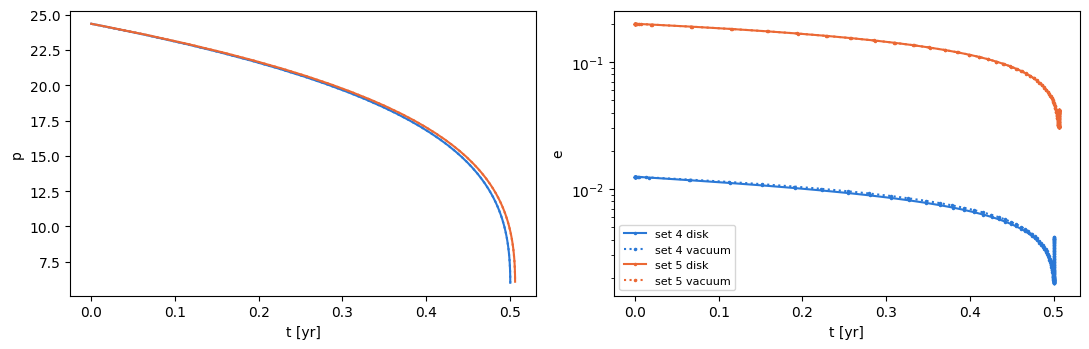

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for tag, col in (("set 4", "#2a78d6"), ("set 5", "#eb6834")):
    for disk, ls in ((True, "-"), (False, ":")):
        tr = wd.trajectory(tag, disk=disk)
        lab = f"{tag} {'disk' if disk else 'vacuum'}"
        axes[0].plot(tr["t_yr"], tr["p"], ls, color=col, label=lab)
        axes[1].plot(tr["t_yr"], tr["e"], ls, color=col, marker=".", ms=3, label=lab)
axes[0].set_ylabel("p"); axes[1].set_ylabel("e"); axes[1].set_yscale("log")
for ax in axes:
    ax.set_xlabel("t [yr]")
axes[1].legend(fontsize=8)
fig.tight_layout()

---
# 6. TDI-null check for every set

Set 4's excess sat at the first-generation TDI null, f = c/(2L) ≈ 0.05996 Hz, where the A/E PSD drops to ~1e-51 and turns a tiny numerical response residual into a huge SNR. This checks **each set as it was fitted (dt = 5, fmax = 0.1)**: the SNR² within ±2 mHz of the null, its share of the total, and the SNR with the band capped at 0.05 Hz.

Rule of thumb: a share above ~1e-3 (0.1%) means the null is shaping that set's inner product and its fits should be redone with fmax = 0.05.

In [18]:
importlib.reload(wd)
NULL_SETS = ["set 1", "set 2", "set 3", "set 4", "set 5"]
null_rows = {}
for tag in NULL_SETS:
    d = wd.load_signal(tag, dt=5.0, fmax=0.1)
    null_rows[tag] = wd.null_contribution(d)
    del d                                  # free the waveform before the next set

print(f"TDI null at {wd.TDI_NULL_HZ:.7f} Hz\n")
print(f"{'set':6}{'SNR (<0.1 Hz)':>15}{'SNR (<0.05 Hz)':>16}{'SNR² near null':>16}{'share':>11}   "
      + "  ".join(f"{c} share" for c in "AET") + "   verdict")
for tag, r in null_rows.items():
    flag = "REDO (fmax 0.05)" if r["share"] > 1e-3 else "ok"
    print(f"{tag:6}{r['snr']:15.4f}{r['snr_below_clean']:16.4f}{r['near_null']:16.4e}{r['share']:11.3e}   "
          + "  ".join(f"{r['channels'][c]['share']:.2e}" for c in "AET") + f"   {flag}")

[CONF] T = 0.503796 yr (0.99 x plunge), dt = 5.0 s, 3 channels, band [1.0e-05, 1.0e-01] Hz
[CONF] T = 0.495744 yr (0.99 x plunge), dt = 5.0 s, 3 channels, band [1.0e-05, 1.0e-01] Hz
[CONF] T = 0.496160 yr (0.99 x plunge), dt = 5.0 s, 3 channels, band [1.0e-05, 1.0e-01] Hz
[CONF] T = 0.495521 yr (0.99 x plunge), dt = 5.0 s, 3 channels, band [1.0e-05, 1.0e-01] Hz
[CONF] T = 0.501229 yr (0.99 x plunge), dt = 5.0 s, 3 channels, band [1.0e-05, 1.0e-01] Hz
TDI null at 0.0599585 Hz

set     SNR (<0.1 Hz)  SNR (<0.05 Hz)  SNR² near null      share   A share  E share  T share   verdict
set 1         85.3661         84.2756      1.8499e+02  2.538e-02   2.53e-02  6.03e-05  3.63e-09   REDO (fmax 0.05)
set 2         82.3148         81.8243      8.0513e+01  1.188e-02   8.73e-03  3.15e-03  1.10e-08   REDO (fmax 0.05)
set 3         82.1978         82.1336      1.0550e+01  1.562e-03   1.38e-03  1.85e-04  6.54e-11   REDO (fmax 0.05)
set 4        351.3474         81.7193      1.1677e+05  9.459e-01   8.84

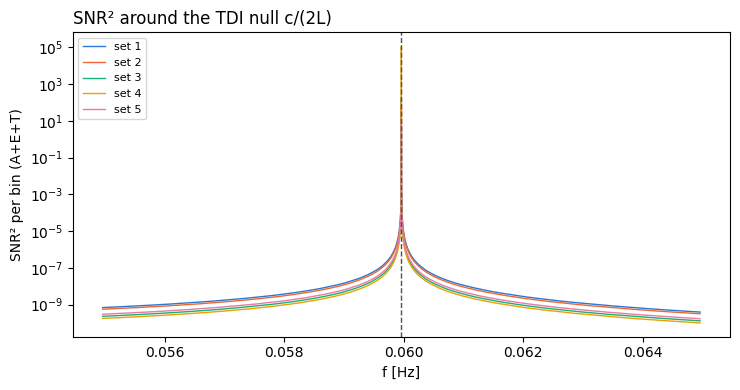

In [19]:
# SNR² per bin around the null, every set
fig, ax = plt.subplots(figsize=(7.5, 4))
SET_COLOR = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
for (tag, r), col in zip(null_rows.items(), SET_COLOR):
    sel = np.abs(r["f"] - wd.TDI_NULL_HZ) < 5e-3
    ax.plot(r["f"][sel], r["density"][:, sel].sum(axis=0), lw=1, color=col, label=tag)
ax.axvline(wd.TDI_NULL_HZ, color="#52514e", ls="--", lw=1)
ax.set_yscale("log"); ax.set_xlabel("f [Hz]"); ax.set_ylabel("SNR² per bin (A+E+T)")
ax.set_title("SNR² around the TDI null c/(2L)", loc="left")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()